# Meta: English vs. German

In [12]:
# Imports
import os, json, sys
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from sqlalchemy.orm import sessionmaker
import numpy as np
import seaborn as sns

In [2]:
# Paths
notebook_path = os.getcwd()
project_root = os.path.dirname(os.path.abspath(notebook_path))
data_dir = os.path.join(project_root, "data")
evaluations_dir = os.path.join(data_dir, "evaluations")
responses_dir = os.path.join(data_dir, "generated")
vocab_dir = os.path.join(data_dir, "vocab")
db_path = os.path.join(data_dir, "DB.db")


In [3]:
# SQL Alchemy session
engine = create_engine(f"sqlite:///{db_path}")
session_factory = sessionmaker(bind=engine)
session = session_factory()

In [4]:
# Helper functions
def get_prompt_eval_dir(prompt_id):
    return os.path.join(evaluations_dir, f"prompt{prompt_id}")

def get_unique_ids(prompt_eval_dir):
    unique_ids = []
    for filename in os.listdir(prompt_eval_dir):
        if filename.endswith(".json"):
            unique_ids.append(filename.split(".json")[0])
    return unique_ids

def load_evaluation(prompt_id):
    prompt_dir = get_prompt_eval_dir(prompt_id)
    unique_ids = get_unique_ids(prompt_dir)
    res = []
    for unique_id in unique_ids:
        file_path = os.path.join(prompt_dir, f"{unique_id}.json")
        with open(file_path, "r", encoding="utf-8") as file:
            res.append(json.load(file))
    return res

def load_evaluations(prompt_ids):
    res_list = []
    for prompt_id in prompt_ids:
        res_list.append(load_evaluation(prompt_id))
    return res_list

In [5]:
# Ground truth
gt_id = "gt.45af4a46-d238-4251-b734-d407602299bd"
gtb_id = "gtb.45af4a46-d258-4251-b734-d407602299bd"

gt_path = os.path.join(evaluations_dir, f"{gt_id}.json")
gtb_path = os.path.join(evaluations_dir, f"{gtb_id}.json")

with open(gt_path, "r", encoding="utf-8") as file:
    gt_res = [json.load(file)]
with open(gt_path, "r", encoding="utf-8") as file:
    gtb_res = [json.load(file)]

## Background

In [13]:
def multi_bar_model_graph(model_res, metric, yinc):
    "show a bar graph of the language tool metrics"
    label_count_dict = {}

    lengths = [
        len(lst) for lst in model_res["metrics"]["language_tool_metrics"][metric]
    ]

    fig, ax = plt.subplots(figsize=(20, 5))

    ax.bar(label_count_dict.keys(), label_count_dict.values())
    ax.grid(True, color="gray", linestyle="--", linewidth=0.5, axis="y")

    ax.bar(
        range(1, len(model_res["metrics"]["language_tool_metrics"][metric]) + 1),
        lengths,
        color="skyblue",
    )

    # Set the labels and title
    ax.set_title(metric + f"{model_res['model']['name']}:{model_res['model']['size']}-{model_res['prompt']['id']}")

     # Set the ticks
    ax.set_xticks(np.arange(1, len(lengths) + 1, 2))
    ax.set_xticklabels(np.arange(1, len(lengths) + 1, 2), rotation=45, ha="center", fontsize=8)
    ax.set_xlim(0, len(lengths) + 0.5)

    ax.set_yticks(np.arange(0, max(lengths) + 1, yinc))
    ax.set_yticklabels(np.arange(0, max(lengths) + 1, yinc), fontsize=8)
    ax.set_ylim(0, max(lengths) + yinc / 2)

    fig.tight_layout()
    return fig, ax

In [9]:
res4 = load_evaluation(4)

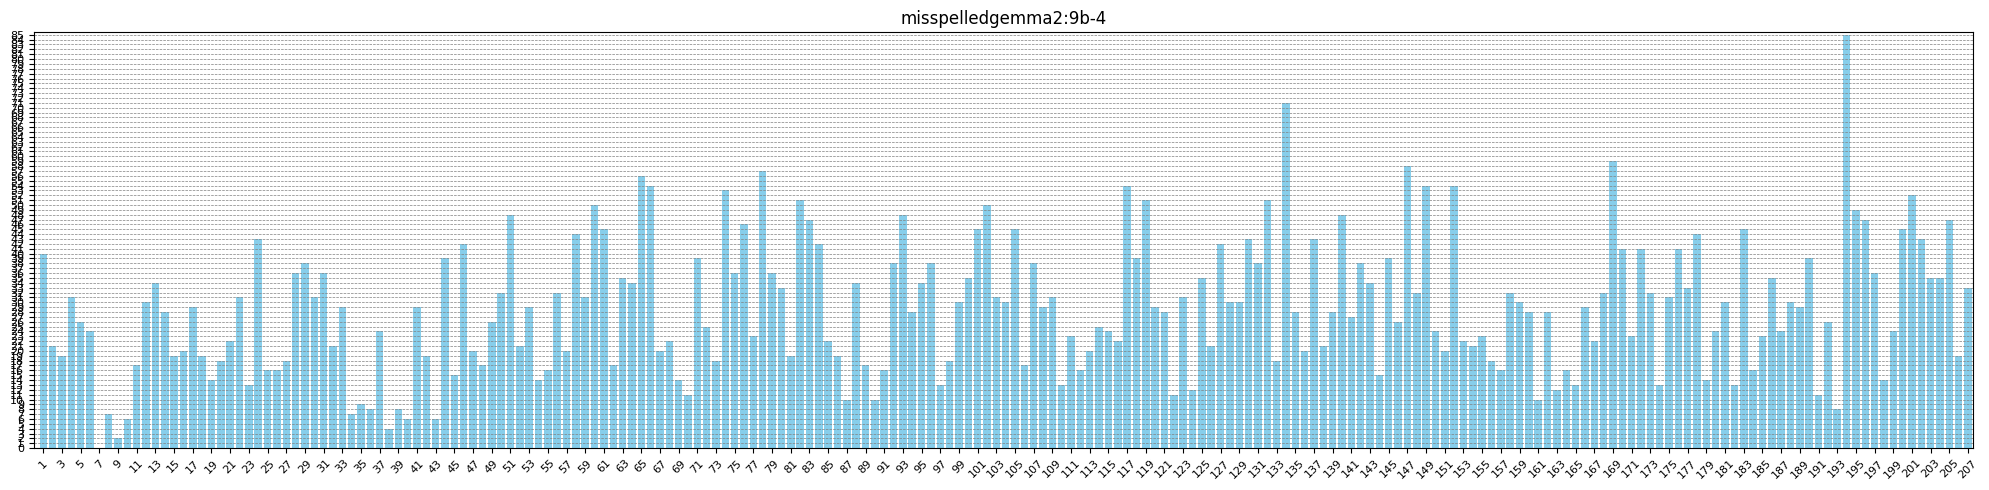

In [17]:
fig, ax = multi_bar_model_graph(res4[1], "misspelled", 1)

## Prompt 4 vs. Prompt 5

- Prompt 4
    > You are a writing assistant system for medical reports written in German that can provide corrected versions of the reports You will only respond with the corrected report. Do not provide explanations.
- Prompt 5
    > Sie sind ein Schreibassistenzsystem für medizinische Berichte, die auf Deutsch geschrieben sind, Sie sollten korrigierte Versionen der Berichte bereitstellen Sie sollten nur mit dem korrigierten Bericht antworten. Sie geben keine Erklärungen ab.

In [6]:
res4, res5 = load_evaluations([4, 5])

## Prompt 8 vs. Prompt 9

- Prompt 8
    >You are a writing assistant system for medical reports at the university hospital of the RWTH Aachen.
    >
    >    At the hospital medical reports are split into the following 5 sections:
    >    1. Kinische Angaben
    >    2. Fragestellung
    >    3. Methodik
    >    4. Befund
    >    5. Beurteilung
    >
    > Your Job is to correct the Befund section only, you should correct the Befund for grammar, spelling, and other syntax mistakes but you should also attempt to improve coherence and change the tone to be more confident, you should try to keep the Befund structure and sentence order the same if possible.
    >
    >Most crucially above all you are not allowed to change the semantics or meaning of the text nor are you allowed to add new information or omit information, this is of paramount importance as a badly written report is always better than one with incorrect information.
    >
    >Lastly your response should only consist of the corrected Befund and nothing else, do not include formatting and don't provide explanations.
    >
    >The following are the other available sections which you can use as context to help you with this task:
    >Klinische Angaben:
    >
    >{report['klinische_angaben']}
    >
    >Fragestellung:
    >
    >{report['fragestellung']}
    >
    >Methodik:
    >
    >{report['methodik']}
    >
    >Beurteilung:
    >
    >{report['beurteilung']}
    >
    >and here is the Befund section you are supposed to correct:
    >
    >{report['befund']}
- Prompt 9
    > Sie sind ein Schreibassistenzsystem für medizinische Berichte, die auf Deutsch geschrieben sind, Sie sollten korrigierte Versionen der Berichte bereitstellen Sie sollten nur mit dem korrigierten Bericht antworten. Sie geben keine Erklärungen ab.

In [7]:
res8, res9 = load_evaluations([8,9])

## Prompt 10 vs. Prompt 11

- Prompt 4
    > You are a writing assistant system for medical reports written in German that can provide corrected versions of the reports You will only respond with the corrected report. Do not provide explanations.
- Prompt 5
    > Sie sind ein Schreibassistenzsystem für medizinische Berichte, die auf Deutsch geschrieben sind, Sie sollten korrigierte Versionen der Berichte bereitstellen Sie sollten nur mit dem korrigierten Bericht antworten. Sie geben keine Erklärungen ab.

In [8]:
res10, res11 = load_evaluations([10,11])